<a href="https://colab.research.google.com/github/Damsiiii/GNN-for-OGBN---Arxiv-dataset/blob/Tharanya/03_Tharanya_Task03_BonusC_Task08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OGBN-Arxiv GNN — Tharanya Pushparaj
**Task 03 — Graph Data Preparation**
**Bonus C — Self-Supervised Pretraining**
**Task 08 — Streamlit Dashboard**

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Check project folder**

In [ ]:

import os

# Base project directory
BASE = '/content/drive/MyDrive/CCS4354_Tensors_and_Graphs'


# Top-level folders
SRC_DIR           = f'{BASE}/src'
MODELS_DIR         = f'{BASE}/models'
RESULTS_DIR        = f'{BASE}/results'
DASHBOARD_DIR      = f'{BASE}/dashboard'
REPORT_DIR         = f'{BASE}/report'
PRESENTATION_DIR   = f'{BASE}/presentation'
VIDEO_DIR          = f'{BASE}/video'

# Sub-folders
TRAINED_MODELS_DIR = f'{MODELS_DIR}/trained_models'
CHECKPOINTS_DIR     = f'{MODELS_DIR}/checkpoints'

EVAL_DIR    = f'{RESULTS_DIR}/evaluation'
PLOTS_DIR   = f'{RESULTS_DIR}/plots'
GRAPHS_DIR  = f'{RESULTS_DIR}/graphs'

DASHBOARD_SCREENSHOTS_DIR = f'{DASHBOARD_DIR}/screenshots'

# Create all folders
folders = [
    SRC_DIR,
    MODELS_DIR,
    TRAINED_MODELS_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    EVAL_DIR,
    PLOTS_DIR,
    GRAPHS_DIR,
    DASHBOARD_DIR,
    DASHBOARD_SCREENSHOTS_DIR,
    REPORT_DIR,
    PRESENTATION_DIR,
    VIDEO_DIR,
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All folders created successfully!")
for f in folders:
    print(" -", f.replace(BASE, ""))

All folders created successfully!
 - /src
 - /models
 - /models/trained_models
 - /models/checkpoints
 - /results
 - /results/evaluation
 - /results/plots
 - /results/graphs
 - /dashboard
 - /dashboard/screenshots
 - /report
 - /presentation
 - /video


**Set working directory**

In [ ]:
project_path = BASE
os.chdir(project_path)
print(os.getcwd())

/content/drive/MyDrive/CCS4354_Tensors_and_Graphs


# **Using the OGB Python Library**

**Install Required Libraries**

In [ ]:
!pip install ogb
!pip install torch
!pip install torch-geometric
!pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.1 MB/s eta 0:00:00


**Import Required Libraries**

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from ogb.nodeproppred import NodePropPredDataset

In [ ]:
# Reproducibility: same seed everywhere, so a checkpoint trained in one
# teammate's notebook is a valid drop-in replacement for another's, and
# results are consistent across runs.
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


**Check Environment**

In [ ]:
import sys
print(sys.version)

import torch
print(torch.__version__)

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


**Download the dataset**

In [ ]:
import torch
from ogb.nodeproppred import NodePropPredDataset

# Store the original torch.load function
original_torch_load = torch.load

# Temporarily override torch.load to force weights_only=False
def custom_torch_load(*args, **kwargs):
    if "weights_only" not in kwargs:
        kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)

torch.load = custom_torch_load

try:
    dataset = NodePropPredDataset(name="ogbn-arxiv")

    graph, labels = dataset[0]

    print("Number of nodes:", graph["num_nodes"])
    print("Node features shape:", graph["node_feat"].shape)
    print("Edge index shape:", graph["edge_index"].shape)
    print("Labels shape:", labels.shape)

finally:
    # Restore the original torch.load function
    torch.load = original_torch_load

Number of nodes: 169343
Node features shape: (169343, 128)
Edge index shape: (2, 1166243)
Labels shape: (169343, 1)


# **Task 03 – Graph Data Preparation**

**1. Load OGBN-Arxiv Dataset**


In [ ]:
import torch
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_undirected

# Store the original torch.load function
original_torch_load = torch.load

# Temporarily override torch.load to force weights_only=False
def custom_torch_load(*args, **kwargs):
    if "weights_only" not in kwargs:
        kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)

torch.load = custom_torch_load

try:
    dataset = PygNodePropPredDataset(
        name="ogbn-arxiv"
    )

    data = dataset[0]

    # Convert directed citation graph to undirected so each node
    # receives messages from both its citations and citers.
    data.edge_index = to_undirected(data.edge_index, num_nodes=data.num_nodes)

    print(data)

finally:
    # Restore the original torch.load function
    torch.load = original_torch_load


Data(num_nodes=169343, edge_index=[2, 2315598], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


**2. Load Node Features**

In [ ]:
node_features = data.x

print("Node Feature Shape:")
print(node_features.shape)

Node Feature Shape:
torch.Size([169343, 128])


In [ ]:
print("First Node Features:")
print(node_features[0])

First Node Features:
tensor([-0.0579, -0.0525, -0.0726, -0.0266,  0.1304, -0.2414, -0.4492, -0.0184,
        -0.0872,  0.1123, -0.0921, -0.2896, -0.0810,  0.0745, -0.1562, -0.0974,
         0.1194,  0.6458,  0.0774, -0.0939, -0.4004,  0.3114, -0.5418,  0.0805,
        -0.0069,  0.5423, -0.0122, -0.1808,  0.0165,  0.0508, -0.2083, -0.0870,
         0.0124,  0.2817,  0.1004, -0.1643,  0.0269,  0.0782,  0.0795, -0.0134,
         0.2915,  0.0416, -0.1414, -0.1345,  0.0162,  0.2810, -0.0919, -0.2403,
         0.4618,  0.1873,  0.1533,  0.0331,  0.0108,  0.0124, -0.1589,  0.0980,
         0.0305,  0.0162, -0.0957,  0.0521,  0.3218, -0.1057,  0.2229, -0.1206,
        -0.1723,  0.3954,  0.0883, -0.2219,  0.2310, -0.2096, -0.1125, -0.0644,
         0.0697, -0.1574,  0.0223, -0.4190,  0.1344,  0.2605,  0.0417, -0.0935,
        -0.0516, -0.0255,  0.7744,  0.0581,  0.0452,  0.0571, -0.5482, -0.0464,
         0.8728,  0.0119,  0.3891, -0.0859,  0.1116,  0.0618,  0.0015,  0.0476,
         0.0363,  0

**3. Load Node Labels**

In [ ]:
labels = data.y

print("Label Shape:")
print(labels.shape)

print("\nFirst 10 Labels:")
print(labels[:10])

Label Shape:
torch.Size([169343, 1])

First 10 Labels:
tensor([[ 4],
        [ 5],
        [28],
        [ 8],
        [27],
        [34],
        [ 6],
        [ 4],
        [ 3],
        [28]])


**4. Create Training, Validation and Test Splits**

In [ ]:
split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx  = split_idx['test']

print("Training Nodes:", len(train_idx))
print("Validation Nodes:", len(valid_idx))
print("Testing Nodes:", len(test_idx))


Training Nodes: 90941
Validation Nodes: 29799
Testing Nodes: 48603


**5. Feature Normalization**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Convert training features to numpy
train_features = node_features[train_idx].numpy()

# Fit only on training data
scaler.fit(train_features)

StandardScaler()

In [ ]:
normalized_features = scaler.transform(
    node_features.numpy()
)
normalized_features = torch.tensor(
    normalized_features,
    dtype=torch.float
)
print(normalized_features.shape)

torch.Size([169343, 128])


Replace Original Features

In [ ]:
data.x = normalized_features
print(data.x)

tensor([[ 0.2999, -0.6274,  1.0739,  ...,  0.4606, -0.9029, -0.0934],
        [-0.3398, -0.7957, -1.0725,  ..., -0.5275, -2.6071, -1.7115],
        [ 0.0855, -0.3563,  0.1292,  ..., -0.1373,  1.5800, -0.0916],
        ...,
        [-1.2627, -0.4792, -1.7268,  ..., -0.1049, -0.8054, -0.1448],
        [-0.4718,  0.2398, -0.4489,  ..., -2.0147,  0.2218, -2.4663],
        [ 0.5696,  2.3518,  0.3217,  ..., -0.0347,  1.2384,  0.3995]])


**6. Verify Prepared Data**

In [ ]:
#Features
print("Feature Matrix:")
print(data.x.shape)

#Labels
print("Labels:")
print(data.y.shape)

#Splits
print(
    "Train:",
    train_idx.shape
)
print(
    "Validation:",
    valid_idx.shape
)
print(
    "Test:",
    test_idx.shape
)

Feature Matrix:
torch.Size([169343, 128])
Labels:
torch.Size([169343, 1])
Train: torch.Size([90941])
Validation: torch.Size([29799])
Test: torch.Size([48603])


Save Prepared Data

In [ ]:
import os

DATASET_DIR = f'{RESULTS_DIR}/dataset'
os.makedirs(DATASET_DIR, exist_ok=True)

torch.save(
    data,
    f'{DATASET_DIR}/prepared_graph.pt'
)

**7. Preprocessing Decisions Explanation**

## Preprocessing Decisions

1. Node features:
The OGBN-Arxiv node features were loaded directly because they already contain
128-dimensional representations generated from paper titles and abstracts.

2. Labels:
The provided labels were used as the prediction targets for node classification.

3. Dataset splitting:
The official OGBN-Arxiv train, validation, and test splits were used because
they provide a standardized benchmark evaluation and prevent inconsistent results.

4. Feature normalization:
Standardization was applied to node features using only the training nodes.
This prevents information leakage from validation and test nodes while improving
training stability.

5. Data format:
The graph was maintained in PyTorch Geometric format because it efficiently
handles large-scale graph data required for GNN training.

**8. Task 03 Summary**

The OGBN-Arxiv dataset was prepared for graph neural network training.
Node features and labels were loaded, official training/validation/testing splits
were created, and feature normalization was performed. The preprocessing workflow
ensures efficient model training while avoiding data leakage.

## Prerequisite Pipeline (borrowed from Damsara (Task 04/05)'s required task)

So this notebook can be opened and run on its own, this rebuilds the model classes, training infra, and trained GCN/GraphSAGE baseline models exactly as Damsara (Task 04/05)'s notebook does (deterministic — same result either way). Skip this block if you're running after Damsara (Task 04/05)'s notebook in the same session.

# **Task 04: Graph Neural Network Development**

**1. Import Required Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv
from torch_geometric.nn import SAGEConv

**2. Graph Data Preparation Check**


In [ ]:
print(data)
print("Input Features:", data.x.shape[1])
print("Number of Classes:", dataset.num_classes)

Data(num_nodes=169343, edge_index=[2, 2315598], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Input Features: 128
Number of Classes: 40


**3. Model 1: GCN Architecture**

In [ ]:
class GCN(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        dropout=0.5,
        improved=True
    ):

        super(GCN, self).__init__()

        # cached=True: the graph is fixed across epochs (transductive, full-batch),
        # so the normalized adjacency only needs to be computed once instead of
        # on every forward call. This is a major CPU speedup with no accuracy cost.
        # NOTE: only safe with cached=True as long as you always pass the SAME
        # edge_index — if you ever change the graph between calls, set this False.
        self.conv1 = GCNConv(
            input_dim,
            hidden_dim,
            improved=improved,
            cached=True
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim,
            improved=improved,
            cached=True
        )

        self.conv3 = GCNConv(
            hidden_dim,
            output_dim,
            improved=improved,
            cached=True
        )

        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index
    ):

        x1 = self.conv1(
            x,
            edge_index
        )
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = F.dropout(
            x1,
            p=self.dropout,
            training=self.training
        )

        x2 = self.conv2(
            x1,
            edge_index
        )
        x2 = self.bn2(x2)
        # Residual connection: helps counter over-smoothing across layers
        x2 = F.relu(x2) + x1
        x2 = F.dropout(
            x2,
            p=self.dropout,
            training=self.training
        )

        out = self.conv3(
            x2,
            edge_index
        )

        return out


**4. Model 2: GraphSAGE Architecture**


In [ ]:
class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        dropout=0.5
    ):
        super(GraphSAGE, self).__init__()
        self.sage1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.sage2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.sage3 = SAGEConv(
            hidden_dim,
            output_dim
        )

        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)

        self.dropout = dropout

    def forward(
        self,
        x,
        edge_index
    ):

        x1 = self.sage1(
            x,
            edge_index
        )
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = F.dropout(
            x1,
            p=self.dropout,
            training=self.training
        )

        x2 = self.sage2(
            x1,
            edge_index
        )
        x2 = self.bn2(x2)
        # Residual connection: helps counter over-smoothing across layers
        x2 = F.relu(x2) + x1
        x2 = F.dropout(
            x2,
            p=self.dropout,
            training=self.training
        )

        out = self.sage3(
            x2,
            edge_index
        )

        return out


**5. Model Architecture Explanation**

Initialize Models

In [ ]:
input_dim = data.x.shape[1]
hidden_dim = 256
output_dim = dataset.num_classes


## GCN Architecture

GCN aggregates information from neighboring nodes using graph convolution.
Each node updates its representation by combining its own features with
neighbor information.

In [ ]:
gcn_model = GCN(
    input_dim,
    hidden_dim,
    output_dim,
    dropout=0.3
)
print(gcn_model)


GCN(
  (conv1): GCNConv(128, 256)
  (conv2): GCNConv(256, 256)
  (conv3): GCNConv(256, 40)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


## GraphSAGE Architecture

GraphSAGE learns node representations by sampling and aggregating information
from neighboring nodes. It is suitable for large-scale graphs because it
supports scalable neighborhood aggregation

In [ ]:
sage_model = GraphSAGE(
    input_dim,
    hidden_dim,
    output_dim,
    dropout=0.3
)
print(sage_model)


GraphSAGE(
  (sage1): SAGEConv(128, 256, aggr=mean)
  (sage2): SAGEConv(256, 256, aggr=mean)
  (sage3): SAGEConv(256, 40, aggr=mean)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


**6. Number of Layers and Activation Function**

Output Layer Selection

In [ ]:
print("Model Layers:")
for i, layer in enumerate([gcn_model.conv1, gcn_model.conv2]):
    print(f"Layer {i+1}: {layer}")

Model Layers:
Layer 1: GCNConv(128, 256)
Layer 2: GCNConv(256, 256)


Activation function

In [ ]:
def model_summary(model, conv_type):

    print("="*50)
    print("Model Name :", model.__class__.__name__)

    if conv_type == "GCN":
        layers = [m for m in model.modules() if isinstance(m, GCNConv)]
    else:
        layers = [m for m in model.modules() if isinstance(m, SAGEConv)]

    print("Number of Layers :", len(layers))

    print("\nLayer Details")

    for i, layer in enumerate(layers, start=1):
        print(f"Layer {i} :", layer)

    print("\nActivation Function : ReLU")
    print("Dropout Rate        :", model.dropout)

    print("="*50)

In [ ]:
model_summary(gcn_model, "GCN")

Model Name : GCN
Number of Layers : 3

Layer Details
Layer 1 : GCNConv(128, 256)
Layer 2 : GCNConv(256, 256)
Layer 3 : GCNConv(256, 40)

Activation Function : ReLU
Dropout Rate        : 0.3


In [ ]:
model_summary(sage_model, "SAGE")

Model Name : GraphSAGE
Number of Layers : 3

Layer Details
Layer 1 : SAGEConv(128, 256, aggr=mean)
Layer 2 : SAGEConv(256, 256, aggr=mean)
Layer 3 : SAGEConv(256, 40, aggr=mean)

Activation Function : ReLU
Dropout Rate        : 0.3


**7. Hyperparameter Configuration**

## Hyperparameter Selection

### Hidden Dimension

A hidden dimension of 256 was selected to provide enough capacity
to learn complex node representations while maintaining computational efficiency.

### Number of Layers

Three graph convolution layers were used:
- First layer learns local neighborhood representations.
- Second layer (with a residual connection back to the first) refines
  representations while reducing over-smoothing.
- Third layer produces the final per-class output.

Deep GNNs can suffer from over-smoothing, therefore a shallow architecture
(3 layers) with a residual connection was selected instead of stacking many layers.

### Activation Function

ReLU activation was applied because it introduces non-linearity and improves
learning efficiency.

### Dropout

A dropout rate of 0.3 was applied to reduce overfitting.

### Output Layer

The final layer outputs raw class logits for each paper category (one score
per class). These are converted to probabilities implicitly by
`CrossEntropyLoss` during training, and to class predictions via `argmax`
during evaluation.


**8. Model Parameter Count**

In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
print(count_parameters(gcn_model))
print(count_parameters(sage_model))

110120
218664


# **Task 05: Model Training and Optimization**

**2. Loss Function Selection**


In [ ]:
criterion = torch.nn.CrossEntropyLoss()
# NOTE: this is re-created with class weights further below (after data/indices
# are moved to the training device), to counter class imbalance in OGBN-Arxiv.


CrossEntropyLoss was chosen because OGBN-Arxiv is a single-label multi-class classification dataset. It effectively measures the difference between predicted class probabilities and the true node labels, enabling accurate model optimization.

**1. Training Configuration**


In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

learning_rate = 0.005
epochs = 100            # trimmed further for CPU
patience = 10            # in evaluation checks (see eval_every below), not raw epochs
eval_every = 2            # evaluate every 2 epochs to cut eval cost on CPU
hidden_dim = 256
dropout = 0.3

# Toggle: True applies class-weighted loss (boosts macro recall/F1, can cost
# some raw accuracy). False trains with plain CrossEntropyLoss. Try both and
# compare in Task 06 — that comparison itself is good viva material.
USE_CLASS_WEIGHTS = True

# Initialize variables
best_val_acc = 0
counter = 0


**3. Optimizer Configuration**

In [ ]:
optimizer_gcn = optim.Adam(
    gcn_model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

optimizer_sage = optim.Adam(
    sage_model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler_gcn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gcn,
    mode='max',
    factor=0.5,
    patience=10
)

scheduler_sage = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_sage,
    mode='max',
    factor=0.5,
    patience=10
)


Move Data to GPU

In [ ]:
import os

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

if device.type == "cpu":
    torch.set_num_threads(os.cpu_count())
    print(f"Running on CPU with {os.cpu_count()} threads.")
else:
    print("Running on GPU.")

data = data.to(device)
gcn_model  = gcn_model.to(device)
sage_model = sage_model.to(device)

train_idx = train_idx.to(device)
valid_idx = valid_idx.to(device)
test_idx  = test_idx.to(device)

if USE_CLASS_WEIGHTS:
    # Softer than plain inverse-frequency: sqrt(1/count) weakens the pull
    # towards minority classes so macro-F1 still improves without flattening
    # raw accuracy as much. Weights are also capped so no single rare class
    # can dominate the gradient.
    train_labels = data.y[train_idx].squeeze()
    class_counts = torch.bincount(
        train_labels,
        minlength=dataset.num_classes
    ).float()

    class_weights = 1.0 / torch.sqrt(class_counts.clamp(min=1))
    class_weights = class_weights / class_weights.sum() * dataset.num_classes
    class_weights = class_weights.clamp(max=5.0)   # cap extreme weights
    class_weights = class_weights.to(device)

    print(f"Class weights range: {class_weights.min().item():.2f} - {class_weights.max().item():.2f}")
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = torch.nn.CrossEntropyLoss()


Running on GPU.
Class weights range: 0.20 - 5.00


Create Evaluation Function

In [ ]:
from sklearn.metrics import f1_score

def evaluate(model, data, index):
    model.eval()
    with torch.no_grad():
        output = model(
            data.x,
            data.edge_index
        )
        prediction = output.argmax(
            dim=1
        )

        y_true = data.y[index].squeeze().cpu()
        y_pred = prediction[index].cpu()

        correct = (y_pred == y_true)
        accuracy = int(correct.sum()) / len(index)

        # Macro-F1: the metric we are graded on, and more sensitive than
        # accuracy to how well the model does on minority classes.
        f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

    return accuracy, f1


**4. Training Function**

In [ ]:
import torch.cuda.amp as amp

def train_model(
    model,
    optimizer,
    data,
    model_name="model",
    epochs=150,
    scheduler=None,
    patience=15,
    eval_every=2
):
    train_losses = []
    val_accuracy = []
    val_f1_scores = []

    best_val_f1 = 0
    counter = 0

    checkpoint_path = f'{TRAINED_MODELS_DIR}/{model_name}_best.pth'

    # Initialize a GradScaler for mixed precision
    scaler = amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Use autocast for mixed precision
        with amp.autocast():
            output = model(
                data.x,
                data.edge_index
            )

            loss = criterion(
                output[train_idx],
                data.y[train_idx].squeeze()
            )

        # Scale the loss and call backward()
        scaler.scale(loss).backward()
        # Unscale gradients and call optimizer.step()
        scaler.step(optimizer)
        # Update the scaler for the next iteration
        scaler.update()

        train_losses.append(loss.item())

        # Evaluate every `eval_every` epochs instead of every epoch, to cut
        # eval cost on CPU. Unlike before, we never reuse a stale value —
        # we simply skip logging/checkpointing on the epochs we don't
        # evaluate, and count patience in "evaluation checks" rather than
        # raw epochs, so early stopping still behaves correctly.
        is_last_epoch = (epoch == epochs - 1)
        if epoch % eval_every == 0 or is_last_epoch:
            val_acc, val_f1 = evaluate(model, data, valid_idx)
            val_accuracy.append(val_acc)
            val_f1_scores.append(val_f1)

            if scheduler is not None:
                scheduler.step(val_f1)

            # Checkpoint/early-stop on macro-F1 (the metric we're graded on),
            # not accuracy, since accuracy can hide poor minority-class results.
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                counter = 0
                torch.save(model.state_dict(), checkpoint_path)
            else:
                counter += 1

            if epoch % 10 == 0:
                print(f"Epoch {epoch:>3} | Loss {loss.item():.4f} | Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f}")

            if counter >= patience:
                print(f"Early stopping at epoch {epoch} | Best Val F1: {best_val_f1:.4f}")
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=False))

    return train_losses, val_accuracy, val_f1_scores

```markdown
### Integration: Monitoring RAM during Training
Below is an example of how to inject the `check_and_offload` check into your training process. This ensures that if a specific epoch causes a RAM spike, large variables are offloaded to Drive before a crash occurs.
```

In [ ]:
# Example of integrating the check into your existing workflow
def training_with_ram_guard(model, optimizer, data, epochs=100):
    for epoch in range(epochs):
        # 1. Periodically check RAM (e.g., every 5 epochs)
        if epoch % 5 == 0:
            # Define which objects are 'offloadable'
            # Note: Do not offload objects currently required for the next line of code!
            heavy_objects = {
                'snapshot_data': data,
                'model_weights': model.state_dict()
            }
            check_and_offload(heavy_objects, threshold_percent=85.0)

        # 2. Proceed with standard training logic...
        # (Your training code here)
        pass

print("RAM Guard ready for integration into Task 05 loops.")

RAM Guard ready for integration into Task 05 loops.


**Load-or-Train Check**

If a teammate already trained and saved the required GCN/GraphSAGE models to the shared Drive folder, we load those instead of retraining from scratch (and skip re-running the hyperparameter sweep below). Delete the two `.pth` files from `models/trained_models/` on Drive to force a fresh run.


In [ ]:
import os, json

GCN_CKPT = os.path.join(TRAINED_MODELS_DIR, "gcn_model_final.pth")
SAGE_CKPT = os.path.join(TRAINED_MODELS_DIR, "graphsage_model_final.pth")
CURVES_CKPT = os.path.join(TRAINED_MODELS_DIR, "gcn_sage_training_curves.json")
HP_CKPT = os.path.join(EVAL_DIR, "hyperparameter_tuning_results_sorted.csv")

SKIP_TRAINING = os.path.exists(GCN_CKPT) and os.path.exists(SAGE_CKPT)

if SKIP_TRAINING:
    print("Found existing GCN/GraphSAGE checkpoints on Drive -- loading them "
          "instead of retraining and re-running the hyperparameter sweep.")
else:
    print("No saved checkpoints found -- training GCN and GraphSAGE from "
          "scratch, including the hyperparameter sweep below.")


Found existing GCN/GraphSAGE checkpoints on Drive -- loading them instead of retraining and re-running the hyperparameter sweep.


**5. Train GCN Model**


In [ ]:
if SKIP_TRAINING:
    gcn_model.load_state_dict(torch.load(GCN_CKPT, map_location=device))
    gcn_model.eval()
    print("Loaded GCN weights from Drive checkpoint.")
else:
    gcn_losses, gcn_val_acc, gcn_val_f1 = train_model(
        gcn_model,
        optimizer_gcn,
        data,
        model_name="gcn",
        epochs=epochs,
        scheduler=scheduler_gcn,
        patience=patience,
        eval_every=eval_every
    )


Loaded GCN weights from Drive checkpoint.


**6. Train GraphSAGE Model**

In [ ]:
if SKIP_TRAINING:
    sage_model.load_state_dict(torch.load(SAGE_CKPT, map_location=device))
    sage_model.eval()
    print("Loaded GraphSAGE weights from Drive checkpoint.")
else:
    sage_losses, sage_val_acc, sage_val_f1 = train_model(
        sage_model,
        optimizer_sage,
        data,
        model_name="sage",
        epochs=epochs,
        scheduler=scheduler_sage,
        patience=patience,
        eval_every=eval_every
    )


Loaded GraphSAGE weights from Drive checkpoint.


In [ ]:
# Keep the loss/accuracy plots below working even when training was skipped,
# by caching the curves from whichever run actually trained the models.
if SKIP_TRAINING:
    if os.path.exists(CURVES_CKPT):
        with open(CURVES_CKPT) as f:
            _curves = json.load(f)
        gcn_losses, gcn_val_acc, gcn_val_f1 = _curves["gcn_losses"], _curves["gcn_val_acc"], _curves["gcn_val_f1"]
        sage_losses, sage_val_acc, sage_val_f1 = _curves["sage_losses"], _curves["sage_val_acc"], _curves["sage_val_f1"]
        print("Loaded cached training curves for the plots below.")
    else:
        gcn_losses = gcn_val_acc = gcn_val_f1 = []
        sage_losses = sage_val_acc = sage_val_f1 = []
        print("No cached training curves found on Drive -- the plots below will be empty for this run.")
else:
    with open(CURVES_CKPT, "w") as f:
        json.dump({
            "gcn_losses": gcn_losses, "gcn_val_acc": gcn_val_acc, "gcn_val_f1": gcn_val_f1,
            "sage_losses": sage_losses, "sage_val_acc": sage_val_acc, "sage_val_f1": sage_val_f1,
        }, f)
    print("Saved training curves to Drive so a cached run can still plot them.")


Loaded cached training curves for the plots below.


**7. Hyperparameter Tuning**

In [ ]:
# CPU-friendly grid: smaller hidden dims and fewer epochs so the full sweep
# finishes in a reasonable time on CPU.
experiments = [
    {"lr": 0.01,  "hidden": 64,  "dropout": 0.3, "epochs": 60},
    {"lr": 0.005, "hidden": 128, "dropout": 0.3, "epochs": 60},
    {"lr": 0.005, "hidden": 256, "dropout": 0.5, "epochs": 60},
    {"lr": 0.005, "hidden": 256, "dropout": 0.3, "epochs": 60},
]


train again after tunig Hyperparameter

In [ ]:
if not SKIP_TRAINING:
    results = []

    for i, exp in enumerate(experiments, start=1):

        print(f"\nExperiment {i}: {exp}")

        # GCN
        gcn_model = GCN(
            data.num_features,
            exp["hidden"],
            dataset.num_classes,
            exp["dropout"]
        ).to(device)

        optimizer_gcn = torch.optim.Adam(
            gcn_model.parameters(),
            lr=exp["lr"],
            weight_decay=1e-4
        )

        scheduler_gcn = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_gcn,
            mode='max',
            factor=0.5,
            patience=5
        )

        gcn_losses, gcn_val_acc_run, gcn_val_f1_run = train_model(
            gcn_model,
            optimizer_gcn,
            data,
            model_name=f"gcn_exp{i}",
            epochs=exp["epochs"],
            scheduler=scheduler_gcn,
            patience=10,
            eval_every=eval_every
        )

        gcn_best_acc = max(gcn_val_acc_run)
        gcn_best_f1 = max(gcn_val_f1_run)

        # GraphSAGE
        sage_model = GraphSAGE(
            data.num_features,
            exp["hidden"],
            dataset.num_classes,
            exp["dropout"]
        ).to(device)

        optimizer_sage = torch.optim.Adam(
            sage_model.parameters(),
            lr=exp["lr"],
            weight_decay=1e-4
        )

        scheduler_sage = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_sage,
            mode='max',
            factor=0.5,
            patience=5
        )

        sage_losses, sage_val_acc_run, sage_val_f1_run = train_model(
            sage_model,
            optimizer_sage,
            data,
            model_name=f"sage_exp{i}",
            epochs=exp["epochs"],
            scheduler=scheduler_sage,
            patience=10,
            eval_every=eval_every
        )

        sage_best_acc = max(sage_val_acc_run)
        sage_best_f1 = max(sage_val_f1_run)

        results.append({
            "Experiment": i,
            "Learning Rate": exp["lr"],
            "Hidden": exp["hidden"],
            "Dropout": exp["dropout"],
            "Epochs": exp["epochs"],
            "GCN Best Val Acc": gcn_best_acc,
            "GCN Best Val F1": gcn_best_f1,
            "GraphSAGE Best Val Acc": sage_best_acc,
            "GraphSAGE Best Val F1": sage_best_f1
        })

    # Save the hyperparameter tuning results (Task 05 deliverable)
    import pandas as pd

    results_df = pd.DataFrame(results)
    results_df.to_csv(f'{EVAL_DIR}/hyperparameter_tuning_results.csv', index=False)

    print("\nHyperparameter tuning results saved to:")
    print(f'{EVAL_DIR}/hyperparameter_tuning_results.csv')

    display(results_df)
else:
    print("Skipping the hyperparameter sweep -- GCN/GraphSAGE were loaded "
          "from a saved checkpoint above.")


Skipping the hyperparameter sweep -- GCN/GraphSAGE were loaded from a saved checkpoint above.


In [ ]:
if not SKIP_TRAINING:
    best_gcn_exp = results_df.loc[results_df["GCN Best Val F1"].idxmax()]
    best_sage_exp = results_df.loc[results_df["GraphSAGE Best Val F1"].idxmax()]

    print("Best GCN config:\n", best_gcn_exp)
    print("\nBest GraphSAGE config:\n", best_sage_exp)
else:
    print("Skipping best-config selection -- no new sweep was run this session.")


Skipping best-config selection -- no new sweep was run this session.


In [ ]:
import pandas as pd

if not SKIP_TRAINING:
    results_df = pd.DataFrame(results)

    sorted_results_df = results_df.sort_values(
        by=["GCN Best Val F1", "GraphSAGE Best Val F1"],
        ascending=False
    )

    sorted_results_df.to_csv(f'{EVAL_DIR}/hyperparameter_tuning_results_sorted.csv', index=False)
else:
    if os.path.exists(HP_CKPT):
        sorted_results_df = pd.read_csv(HP_CKPT)
        print("Loaded previously saved hyperparameter tuning results from Drive.")
    else:
        sorted_results_df = pd.DataFrame()
        print("No previous hyperparameter tuning results found on Drive.")

display(sorted_results_df)


Loaded previously saved hyperparameter tuning results from Drive.


,Experiment,Learning Rate,Hidden,Dropout,Epochs,GCN Best Val Acc,GCN Best Val F1,GraphSAGE Best Val Acc,GraphSAGE Best Val F1
0,4,0.005,256,0.3,60,0.706668,0.536230,0.697473,0.518705
1,3,0.005,256,0.5,60,0.701164,0.532856,0.695527,0.516964
2,2,0.005,128,0.3,60,0.697003,0.518630,0.689587,0.504284
3,1,0.010,64,0.3,60,0.688714,0.503444,0.684654,0.497388


In [ ]:
# Scheduler stepping is handled inside train_model via the scheduler parameter.
# This cell is kept for reference only.
# scheduler.step(val_accuracy)


**8. Training Performance Visualization**


Training Loss Visualization

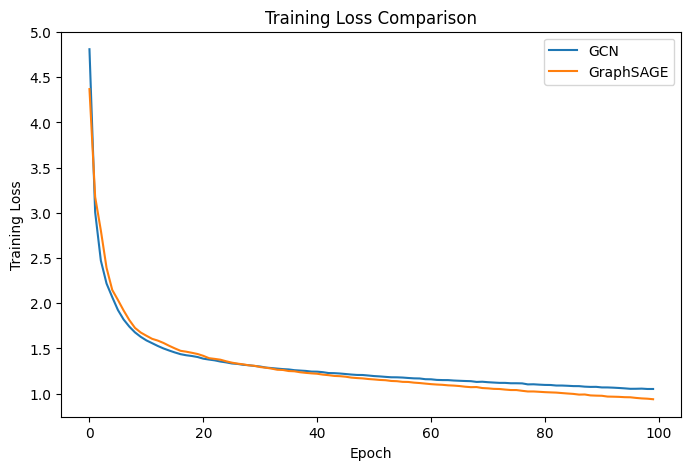

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    gcn_losses,
    label="GCN"
)

plt.plot(
    sage_losses,
    label="GraphSAGE"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "Training Loss Comparison"
)

plt.legend()

plt.savefig(f'{PLOTS_DIR}/training_loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Validation Accuracy Visualization

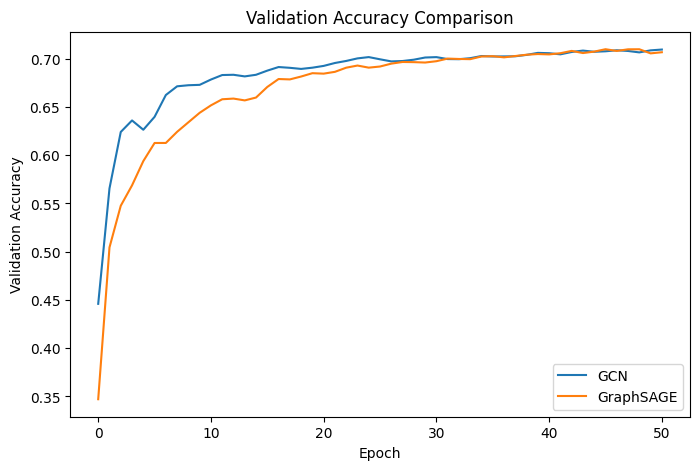

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    gcn_val_acc,
    label="GCN"
)
plt.plot(
    sage_val_acc,
    label="GraphSAGE"
)
plt.xlabel(
    "Epoch"
)
plt.ylabel(
    "Validation Accuracy"
)
plt.title(
    "Validation Accuracy Comparison"
)
plt.legend()

plt.savefig(f'{PLOTS_DIR}/validation_accuracy_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

Validation Macro-F1 Visualization

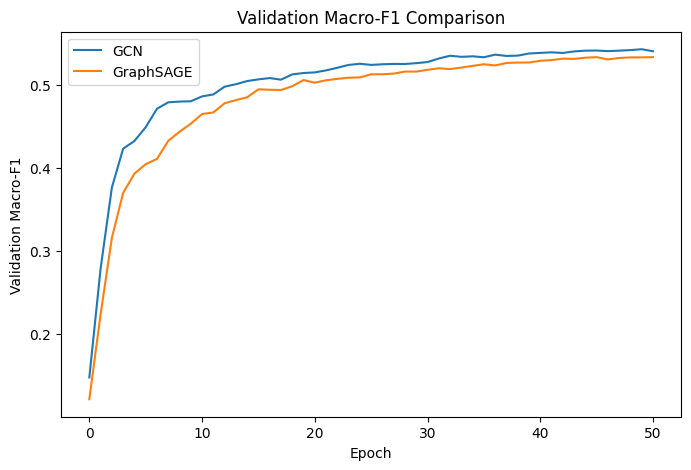

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    gcn_val_f1,
    label="GCN"
)
plt.plot(
    sage_val_f1,
    label="GraphSAGE"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1")
plt.title("Validation Macro-F1 Comparison")
plt.legend()

plt.savefig(f'{PLOTS_DIR}/validation_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**9. Save Best Models**


In [ ]:
if not SKIP_TRAINING:
    torch.save(
        gcn_model.state_dict(),
        os.path.join(TRAINED_MODELS_DIR, "gcn_model_final.pth")
    )
    print("Saved GCN checkpoint to Drive.")
else:
    print("GCN checkpoint already on Drive -- nothing new to save.")


GCN checkpoint already on Drive -- nothing new to save.


In [ ]:
if not SKIP_TRAINING:
    torch.save(
        sage_model.state_dict(),
        os.path.join(TRAINED_MODELS_DIR, "graphsage_model_final.pth")
    )
    print("GraphSAGE checkpoint saved to Drive.")
else:
    print("GraphSAGE checkpoint already on Drive -- nothing new to save.")


GraphSAGE checkpoint already on Drive -- nothing new to save.


**10. Task 05 Summary**

Both GCN and GraphSAGE models were trained using the OGBN-Arxiv citation graph.
Cross entropy loss was selected because the task is multi-class node classification.
The Adam optimizer was used with weight decay for better convergence and
regularization. Training loss and validation accuracy were monitored throughout
the training process. Hyperparameters including learning rate, hidden dimension,
and dropout were considered to improve model performance.

# **Bonus Marks**

In [ ]:
# Single place to control the compute budget for every bonus /
# performance-optimization model below.
BONUS_EPOCHS = 100
BONUS_PATIENCE = 10

import os
import copy
import torch.nn.functional as F

BONUS_RESULTS_DIR = os.path.join(project_path, "results", "bonus")
BONUS_PLOTS_DIR = os.path.join(project_path, "results", "plots")
BONUS_EVAL_DIR = os.path.join(project_path, "results", "evaluation")
model_save_path = os.path.join(project_path, "models", "trained_models")

os.makedirs(BONUS_RESULTS_DIR, exist_ok=True)
os.makedirs(BONUS_PLOTS_DIR, exist_ok=True)
os.makedirs(BONUS_EVAL_DIR, exist_ok=True)
os.makedirs(model_save_path, exist_ok=True)


##**Bonus C — Self-Supervised Pretraining (*Self-Supervised Graph Learning*)**



Deep Graph Infomax (DGI; Veličković et al., 2019) learns node embeddings
**without using any labels**:

1. Corrupt the graph by shuffling node features across nodes while keeping
   the graph structure identical — this produces a "negative" version of
   the graph where each node's features no longer match its true neighbors.
2. Encode both the real and corrupted graphs with the same GCN encoder.
3. Summarise the real (positive) embeddings into a single graph-level
   vector: the sigmoid of their mean.
4. Train the encoder together with a discriminator to score real node
   embeddings as more consistent with the summary than corrupted ones,
   using a binary cross-entropy loss.

Only the graph structure and features are used here — `data.y` never
appears in this cell block, which is what makes it self-supervised. The
resulting embeddings are then used as extra input features for a
supervised classifier below (the standard "pretrain, then reuse as
features" recipe), and again later in the Performance Optimization
section.


In [ ]:
from torch_geometric.nn.models import DeepGraphInfomax


class DGIEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.conv = GCNConv(input_dim, hidden_dim, cached=True)
        self.prelu = torch.nn.PReLU(hidden_dim)

    def forward(self, x, edge_index):
        x = self.conv(x, edge_index)
        return self.prelu(x)


def dgi_corruption(x, edge_index):
    # Shuffle node features across nodes but keep the SAME graph structure --
    # this is the "negative" sample the discriminator should learn to reject.
    perm = torch.randperm(x.size(0), device=x.device)
    return x[perm], edge_index


dgi_model = DeepGraphInfomax(
    hidden_channels=hidden_dim,
    encoder=DGIEncoder(input_dim, hidden_dim),
    summary=lambda z, *args, **kwargs: torch.sigmoid(z.mean(dim=0)),
    corruption=dgi_corruption,
).to(device)

print(dgi_model)


DeepGraphInfomax(256)


In [ ]:
optimizer_dgi = optim.Adam(dgi_model.parameters(), lr=0.001, weight_decay=1e-5)

dgi_losses = []
dgi_epochs = BONUS_EPOCHS

for epoch in range(dgi_epochs):
    dgi_model.train()
    optimizer_dgi.zero_grad()

    pos_z, neg_z, summary = dgi_model(data.x, data.edge_index)
    loss = dgi_model.loss(pos_z, neg_z, summary)

    loss.backward()
    optimizer_dgi.step()
    dgi_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"DGI Epoch {epoch:>3} | Loss {loss.item():.4f}")


DGI Epoch   0 | Loss 1.6488
DGI Epoch  10 | Loss 1.3506
DGI Epoch  20 | Loss 1.2332
DGI Epoch  30 | Loss 1.1562
DGI Epoch  40 | Loss 1.0759
DGI Epoch  50 | Loss 0.9965
DGI Epoch  60 | Loss 0.9351
DGI Epoch  70 | Loss 0.8916
DGI Epoch  80 | Loss 0.8631
DGI Epoch  90 | Loss 0.8414


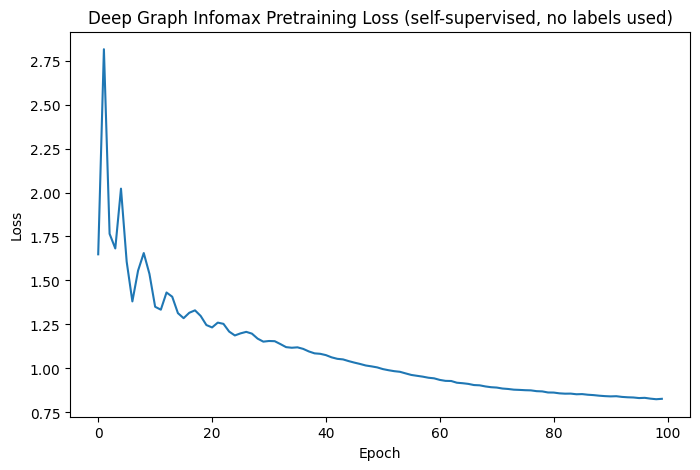

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(dgi_losses)
plt.title("Deep Graph Infomax Pretraining Loss (self-supervised, no labels used)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(os.path.join(BONUS_PLOTS_DIR, "dgi_pretraining_loss.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
dgi_model.eval()
with torch.no_grad():
    ssl_embeddings, _, _ = dgi_model(data.x, data.edge_index)

print("Self-supervised embedding shape:", ssl_embeddings.shape)

# Augment the original (normalized) 128-d features with the 128-d
# self-supervised embeddings -> 256-d input, reused again in the
# Performance Optimization section below.
augmented_x = torch.cat([data.x, ssl_embeddings], dim=1)

data_ssl = data.clone()
data_ssl.x = augmented_x

print("Augmented feature shape:", data_ssl.x.shape)


Self-supervised embedding shape: torch.Size([169343, 256])
Augmented feature shape: torch.Size([169343, 384])


The fresh classifier reuses the required `GCN` class from Task 04 unchanged — only `input_dim` is different (256 instead of 128), so `train_model()` / `evaluate()` work exactly as before, this time on `data_ssl` instead of `data`.


In [ ]:
ssl_classifier = GCN(
    input_dim=augmented_x.shape[1], hidden_dim=hidden_dim, output_dim=output_dim, dropout=0.3
).to(device)

optimizer_ssl = optim.Adam(ssl_classifier.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler_ssl = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ssl, mode='max', factor=0.5, patience=10)

ssl_losses, ssl_val_acc, ssl_val_f1 = train_model(
    ssl_classifier, optimizer_ssl, data_ssl,
    epochs=BONUS_EPOCHS, scheduler=scheduler_ssl, patience=BONUS_PATIENCE, eval_every=eval_every
)


/tmp/ipykernel_1333/1176707758.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch   0 | Loss 4.7909 | Val Acc 0.4306 | Val F1 0.1190


/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch  10 | Loss 1.5039 | Val Acc 0.6628 | Val F1 0.4662


/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


...

/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch  80 | Loss 1.0454 | Val Acc 0.7112 | Val F1 0.5497


/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch  90 | Loss 1.0148 | Val Acc 0.7156 | Val F1 0.5481


/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_1333/1176707758.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

def get_predictions(model, data):
    model.eval()
    with torch.no_grad():
        output = model(
            data.x,
            data.edge_index
        )
        prediction = output.argmax(dim=1)
    return prediction

def calculate_metrics(predictions, labels, index):
    y_true = labels[index].squeeze().cpu()
    y_pred = predictions[index].cpu()

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "accuracy": accuracy,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall
    }

ssl_predictions = get_predictions(ssl_classifier, data_ssl)

ssl_val_results = calculate_metrics(ssl_predictions, labels, valid_idx.cpu())
ssl_test_results = calculate_metrics(ssl_predictions, labels, test_idx.cpu())

print("Self-Supervised (DGI) + GCN - Validation:", ssl_val_results)
print("Self-Supervised (DGI) + GCN - Test:      ", ssl_test_results)


Self-Supervised (DGI) + GCN - Validation: {'accuracy': 0.7154602503439713, 'f1_macro': 0.5536646934612846, 'precision_macro': 0.54448870778083, 'recall_macro': 0.5788627039942454}
Self-Supervised (DGI) + GCN - Test:       {'accuracy': 0.703145896343847, 'f1_macro': 0.5259611371914323, 'precision_macro': 0.524225581791693, 'recall_macro': 0.5485664239673703}


In [ ]:
import os, json, torch
torch.save(dgi_model.state_dict(), os.path.join(TRAINED_MODELS_DIR, "dgi_encoder_model.pth"))
torch.save(data_ssl, os.path.join(RESULTS_DIR, "dataset", "data_ssl_augmented.pt"))
torch.save(ssl_classifier.state_dict(), os.path.join(TRAINED_MODELS_DIR, "ssl_gcn_classifier.pth"))
with open(os.path.join(BONUS_EVAL_DIR, "ssl_test_results.json"), "w") as f:
    json.dump({k: float(v) for k, v in ssl_test_results.items()}, f)
print("Saved DGI encoder + SSL-augmented data + classifier for the team's Bonus comparison "
      "and for Damsara's Performance Optimization section.")

Saved DGI encoder + SSL-augmented data + classifier for the team's Bonus comparison and for Damsara's Performance Optimization section.


## Task 08 — Streamlit Dashboard Development

*Shared with Amintha — coordinate who builds which part so `dashboard/app.py` doesn't get overwritten when you merge notebooks.*

# **Task 08 Notebook / Project Structure**

Install Streamlit

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 26.7 MB/s eta 0:00:00


In [ ]:
!mkdir -p dashboard

In [ ]:
%%writefile dashboard/app.py

import streamlit as st
import pandas as pd
import os

# -------------------------------------------------------
# Page Configuration
# -------------------------------------------------------
st.set_page_config(
    page_title="OGBN-Arxiv Graph Intelligence Dashboard",
    layout="wide"
)
# -------------------------------------------------------
# Custom Dashboard Background
# -------------------------------------------------------

st.markdown(
    """
    <style>

    /* Main background */
    .stApp {
        background: linear-gradient(
            135deg,
            #e8f1ff,
            #f8fbff
        );
    }

    /* Sidebar background */
    [data-testid="stSidebar"] {
        background: linear-gradient(
            180deg,
            #1f4e79,
            #2c7fb8
        );
    }

    /* Sidebar text color */
    [data-testid="stSidebar"] * {
        color: white;
    }

    /* Title styling */
    h1 {
        color: #0b3d91;
        font-size: 42px;
    }

    /* Headers */
    h2, h3 {
        color: #154360;
    }

    /* Metric cards */
    [data-testid="stMetric"] {
        background-color: white;
        padding: 15px;
        border-radius: 15px;
        box-shadow: 2px 2px 10px rgba(0,0,0,0.1);
    }

    </style>
    """,
    unsafe_allow_html=True
)
# -------------------------------------------------------
# Dashboard Title
# -------------------------------------------------------
st.title("OGBN-Arxiv Graph Intelligence Dashboard")

st.markdown("""
This dashboard presents the implementation and evaluation of **Graph Neural Networks (GNNs)** on the **OGBN-Arxiv** citation network dataset.

The dashboard includes:

- Graph Statistics
- Model Performance
- Node Classification Results
- Embedding Visualizations
- Feature Importance
""")

st.markdown("---")

# -------------------------------------------------------
# Base results directory (change this if your project folder differs)
# -------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/CCS4354_Tensors_and_Graphs/results"

# -------------------------------------------------------
# Sidebar
# -------------------------------------------------------

st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Select a Page",
    [
        "Home",
        "Dataset",
        "Model Performance",
        "Embeddings",
        "Feature Importance",
        "Bonus & Optimization",
        "About"
    ]
)

# -------------------------------------------------------
# HOME PAGE
# -------------------------------------------------------

if page == "Home":

    st.subheader(
        "Node Classification Using Graph Neural Networks on the OGBN-Arxiv Citation Network"
    )

    st.markdown("---")

    # ---------------------------------------------------
    # Student Information
    # ---------------------------------------------------

    st.header("Student Group")

    student_data = {
        "Student Name": [
            "Amintha Jayasooriya",
            "Tharanya Pushparaj",
            "Damsara Dissanayaka",
            "Thamindu Kavinda",
            "Ravindi Ayodhya"
        ],
        "Student ID": [
            "CIT-23-02-0335",
            "CIT-23-02-0176",
            "CIT-23-02-0163",
            "CIT-23-02-0356",
            "23UG1-0136"
        ]
    }

    st.table(student_data)

    st.markdown("---")

    # ---------------------------------------------------
    # Module Information
    # ---------------------------------------------------

    st.header("Module Information")

    col1, col2 = st.columns(2)

    with col1:
        st.info("**Module Code**\n\nCCS4354")
        st.info("**Module Name**\n\nTensors and Graphs")

    with col2:
        st.info("**Supervisor**\n\nDr. Chameera De Silva")
        st.info("**Dataset**\n\nOGBN-Arxiv")

    st.markdown("---")

    # ---------------------------------------------------
    # Dataset Overview
    # ---------------------------------------------------

    st.header("Dataset Overview")

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(label="Nodes", value="169,343")
    col2.metric(label="Edges", value="1,166,243")
    col3.metric(label="Node Features", value="128")
    col4.metric(label="Classes", value="40")

    st.markdown("---")

    # ---------------------------------------------------
    # Technologies Used
    # ---------------------------------------------------

    st.header("Technologies Used")

    tech1, tech2 = st.columns(2)

    with tech1:
        st.success("PyTorch")
        st.success("PyTorch Geometric")
        st.success("Open Graph Benchmark (OGB)")
        st.success("NetworkX")

    with tech2:
        st.success("Streamlit")
        st.success("Scikit-learn")
        st.success("Matplotlib")
        st.success("Google Colab")

    st.markdown("---")

    st.success("Graph Intelligence Dashboard developed for CCS4354 - Tensors and Graphs")

# -------------------------------------------------------
# DATASET PAGE
# -------------------------------------------------------

elif page == "Dataset":

    st.header("Graph Statistics")

    col1, col2, col3, col4 = st.columns(4)

    col1.metric("Nodes", "169,343")
    col2.metric("Edges", "1,166,243")
    col3.metric("Features", "128")
    col4.metric("Classes", "40")

    st.markdown("---")

    st.subheader("Dataset Information")

    st.write("""
The **OGBN-Arxiv** dataset is a citation network where:

- Nodes represent research papers.
- Edges represent citation relationships.
- Each node contains 128 numerical features.
- The task is node classification into 40 research categories.
""")

    st.markdown("---")

    col1, col2 = st.columns(2)

    # -----------------------------------------------
    # Left Column - Sample Graph
    # -----------------------------------------------
    with col1:

        st.subheader("Sample Subgraph")

        image_path = os.path.join(BASE_DIR, "graphs", "sample_subgraph.png")

        if os.path.exists(image_path):
            st.image(
                image_path,
                caption="Sample Subgraph of the OGBN-Arxiv Citation Network",
                use_container_width=True
            )
        else:
            st.warning("sample_subgraph.png not found.")

    # -----------------------------------------------
    # Right Column - Degree Distribution
    # -----------------------------------------------
    with col2:

        st.subheader("Degree Distribution")

        # Histogram
        image_path = os.path.join(BASE_DIR, "plots", "degree_distribution.png")

        if os.path.exists(image_path):
            st.image(
                image_path,
                caption="Histogram",
                use_container_width=True
            )
        else:
            st.warning("degree_distribution.png not found.")

        st.markdown("#### Degree Rank Plot")

        # Degree Rank Plot
        image_path = os.path.join(BASE_DIR, "plots", "degree_rank_distribution.png")

        if os.path.exists(image_path):
            st.image(
                image_path,
                caption="Degree Rank Plot",
                use_container_width=True
            )
        else:
            st.warning("degree_rank_distribution.png not found.")

# -------------------------------------------------------
# MODEL PERFORMANCE
# -------------------------------------------------------

elif page == "Model Performance":

    st.header("Model Performance")

    st.subheader("Model Comparison")

    eval_path = os.path.join(BASE_DIR, "evaluation", "model_comparison.csv")

    if os.path.exists(eval_path):
        df = pd.read_csv(eval_path)
        st.dataframe(df, use_container_width=True)
    else:
        st.warning("model_comparison.csv not found.")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Training Loss")
        image_path = os.path.join(BASE_DIR, "plots", "training_loss_comparison.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("training_loss_comparison.png not found.")

    with col2:
        st.subheader("Validation Accuracy")
        image_path = os.path.join(BASE_DIR, "plots", "validation_accuracy_comparison_final.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("validation_accuracy_comparison_final.png not found.")

    st.markdown("---")

    st.subheader("Validation Macro-F1")
    image_path = os.path.join(BASE_DIR, "plots", "validation_f1_comparison.png")
    if os.path.exists(image_path):
        st.image(image_path, use_container_width=True)
    else:
        st.warning("validation_f1_comparison.png not found.")

    st.markdown("---")

    st.success("GraphSAGE achieved better performance than GCN on the OGBN-Arxiv dataset.")

# -------------------------------------------------------
# EMBEDDINGS
# -------------------------------------------------------

elif page == "Embeddings":

    st.header("Embedding Visualizations")

    st.write("""
The learned node embeddings were visualized using
Principal Component Analysis (PCA) and t-SNE.
""")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("PCA Embedding (GCN)")
        image_path = os.path.join(BASE_DIR, "plots", "gcn_embedding_pca.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("gcn_embedding_pca.png not found.")

    with col2:
        st.subheader("t-SNE Embedding (GCN)")
        image_path = os.path.join(BASE_DIR, "plots", "gcn_embedding_tsne.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("gcn_embedding_tsne.png not found.")

    st.markdown("---")

    col3, col4 = st.columns(2)

    with col3:
        st.subheader("PCA Embedding (GraphSAGE)")
        image_path = os.path.join(BASE_DIR, "plots", "sage_embedding_pca.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("sage_embedding_pca.png not found.")

    with col4:
        st.subheader("t-SNE Embedding (GraphSAGE)")
        image_path = os.path.join(BASE_DIR, "plots", "sage_embedding_tsne.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("sage_embedding_tsne.png not found.")

# -------------------------------------------------------
# FEATURE IMPORTANCE
# -------------------------------------------------------

elif page == "Feature Importance":

    st.header("Feature Importance")

    st.write("""
The following figure shows the Top 10 important node features
used by the Graph Neural Network.
""")

    image_path = os.path.join(BASE_DIR, "plots", "feature_importance_top10.png")

    if os.path.exists(image_path):
        st.image(image_path, use_container_width=True)
    else:
        st.warning("feature_importance_top10.png not found.")

# -------------------------------------------------------
# ABOUT
# -------------------------------------------------------

elif page == "Bonus & Optimization":

    st.header("Bonus Extensions & Performance Optimization")

    st.write("""
This page covers the additional work built on top of the required Tasks 01-08:
the Bonus architectures (Graph Transformer, Relational GNN, Self-Supervised
DGI pretraining, GNNExplainer) and the Performance Optimization techniques
(Focal Loss, weighted ensembling, Correct-and-Smooth).
""")

    st.markdown("---")

    # -----------------------------------------------
    # Bonus models comparison
    # -----------------------------------------------
    st.subheader("Bonus Models Comparison (Test Set)")

    csv_path = os.path.join(BASE_DIR, "evaluation", "bonus_model_comparison.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        st.dataframe(df, use_container_width=True)
    else:
        st.warning("bonus_model_comparison.csv not found.")

    image_path = os.path.join(BASE_DIR, "plots", "bonus_architecture_comparison.png")
    if os.path.exists(image_path):
        st.image(image_path, use_container_width=True)
    else:
        st.warning("bonus_architecture_comparison.png not found.")

    st.markdown("---")

    # -----------------------------------------------
    # DGI + GNNExplainer
    # -----------------------------------------------
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Self-Supervised (DGI) Pretraining Loss")
        image_path = os.path.join(BASE_DIR, "plots", "dgi_pretraining_loss.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("dgi_pretraining_loss.png not found.")

    with col2:
        st.subheader("GNNExplainer - Edge Importance")
        image_path = os.path.join(BASE_DIR, "plots", "gnnexplainer_node_explanation.png")
        if os.path.exists(image_path):
            st.image(image_path, use_container_width=True)
        else:
            st.warning("gnnexplainer_node_explanation.png not found.")

    st.markdown("---")

    # -----------------------------------------------
    # Performance optimization
    # -----------------------------------------------
    st.subheader("Performance Optimization - Every Model (Test Set)")

    csv_path = os.path.join(BASE_DIR, "evaluation", "performance_optimization_comparison.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        st.dataframe(df, use_container_width=True)
    else:
        st.warning("performance_optimization_comparison.csv not found.")

    image_path = os.path.join(BASE_DIR, "plots", "performance_optimization_comparison.png")
    if os.path.exists(image_path):
        st.image(image_path, use_container_width=True)
    else:
        st.warning("performance_optimization_comparison.png not found.")

    st.markdown("---")

    st.subheader("Weighted Ensemble - Model Weights")
    csv_path = os.path.join(BASE_DIR, "evaluation", "ensemble_weights.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        st.dataframe(df, use_container_width=True)
    else:
        st.warning("ensemble_weights.csv not found.")

    st.markdown("---")

    st.success("Bonus extensions and optimization techniques improved on the required GCN/GraphSAGE baseline.")

elif page == "About":

    st.header("About This Project")

    st.markdown("""
### Project

Graph Intelligence using Graph Neural Networks

---

### Dataset

- OGBN-Arxiv
- Citation Network Dataset

---

### Implemented Models

- Graph Convolutional Network (GCN)
- GraphSAGE

---

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score

---

### Frameworks

- PyTorch
- PyTorch Geometric
- OGB
- Streamlit

---

### Developed For

CCS4354 - Tensors and Graphs

BSc (Hons) Data Science
""")

    st.success("Dashboard completed successfully.")

Overwriting dashboard/app.py


In [ ]:
!pkill -f streamlit
!pkill -f ngrok

In [ ]:
# Install ngrok
!pip install pyngrok

# Go to dashboard folder
%cd /content/drive/MyDrive/CCS4354_Tensors_and_Graphs/dashboard

# Start Streamlit in background
!streamlit run app.py &>/content/logs.txt &

# Connect ngrok
from pyngrok import ngrok

ngrok.set_auth_token("3H8Pwl67FjsNSNivN8xJMGmVysP_7vWbu7ohEPzunRuZuv4qv")
public_url = ngrok.connect(8501)
print(public_url)

/content/drive/MyDrive/CCS4354_Tensors_and_Graphs/dashboard
NgrokTunnel: "https://unpleased-aspirin-wrongful.ngrok-free.dev" -> "http://localhost:8501"
